In [2]:
# ── Imports ──────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [4]:
# ── Step 1: Load Dataset ──────────────────────────────
df = pd.read_csv('dataset/50_startups_dataset.csv')

In [5]:
print("="*50)
print("DATASET OVERVIEW")
print("="*50)
print("\nFirst 5 rows:")
print(df.head())
print("\nShape:", df.shape)
print("\nData Types:\n", df.dtypes)
print("\nMissing Values:\n", df.isnull().sum())
print("\nStatistics:\n", df.describe())

DATASET OVERVIEW

First 5 rows:
   R&D Spend  Administration  Marketing Spend       State     Profit
0  165349.20       136897.80        471784.10    Pakistan  192261.83
1  162597.70       151377.59        443898.53  California  191792.06
2  153441.51       101145.55        407934.54    Istanbul  191050.39
3  144372.41       118671.85        383199.62    Pakistan  182901.99
4  142107.34        91391.77        366168.42    Istanbul  166187.94

Shape: (50, 5)

Data Types:
 R&D Spend          float64
Administration     float64
Marketing Spend    float64
State                  str
Profit             float64
dtype: object

Missing Values:
 R&D Spend          0
Administration     0
Marketing Spend    0
State              0
Profit             0
dtype: int64

Statistics:
            R&D Spend  Administration  Marketing Spend         Profit
count      50.000000       50.000000        50.000000      50.000000
mean    73721.615600   121344.639600    211025.097800  112012.639200
std     45902.2564

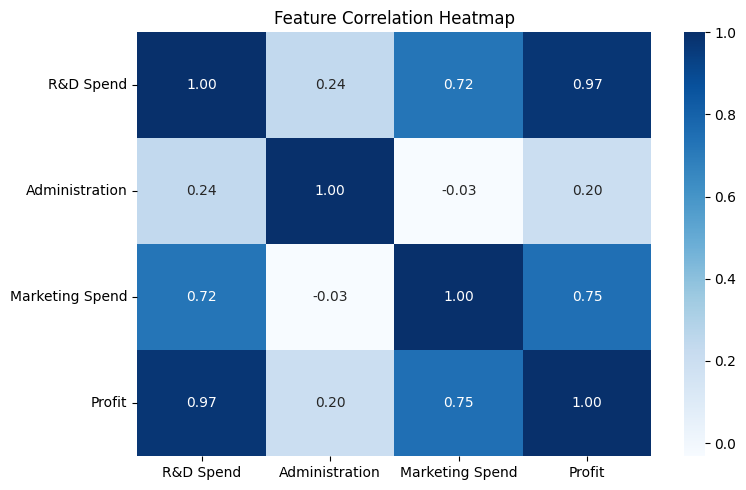

In [6]:
# ── Step 2: EDA - Correlation Heatmap ────────────────
plt.figure(figsize=(8, 5))
sns.heatmap(df.select_dtypes(include='number').corr(),
            annot=True, cmap='Blues', fmt='.2f')
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.savefig('heatmap.png')
plt.show()


In [7]:
# ── Step 3: Preprocessing - One Hot Encoding ─────────
df_encoded = pd.get_dummies(df, columns=['State'], drop_first=True)

print("\nEncoded Columns:", df_encoded.columns.tolist())

X = df_encoded.drop('Profit', axis=1)
y = df_encoded['Profit']


Encoded Columns: ['R&D Spend', 'Administration', 'Marketing Spend', 'Profit', 'State_Istanbul', 'State_Pakistan']


In [8]:
# ── Step 4: Train Test Split ──────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"\nTrain size: {X_train.shape}")
print(f"Test size : {X_test.shape}")


Train size: (40, 5)
Test size : (10, 5)


In [9]:
# ── Step 5: Train Model ───────────────────────────────
model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [10]:
# ── Step 6: Evaluate Model ────────────────────────────
r2   = r2_score(y_test, y_pred)
mae  = mean_absolute_error(y_test, y_pred)
mse  = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print("\n" + "="*50)
print("MODEL EVALUATION")
print("="*50)
print(f"R² Score : {r2:.4f}")
print(f"MAE      : ${mae:,.2f}")
print(f"MSE      : ${mse:,.2f}")
print(f"RMSE     : ${rmse:,.2f}")


MODEL EVALUATION
R² Score : 0.8987
MAE      : $6,961.48
MSE      : $82,010,363.04
RMSE     : $9,055.96


In [11]:
# ── Step 7: Feature Importance (Coefficients) ────────
coef_df = pd.DataFrame({
    'Feature':     X.columns,
    'Coefficient': model.coef_
}).sort_values('Coefficient', key=abs, ascending=False)

print(f"\nIntercept: ${model.intercept_:,.2f}")
print("\nFeature Coefficients:")
print(coef_df.to_string(index=False))


Intercept: $54,028.04

Feature Coefficients:
        Feature  Coefficient
 State_Istanbul   938.793006
 State_Pakistan     6.987760
      R&D Spend     0.805630
 Administration    -0.068788
Marketing Spend     0.029855


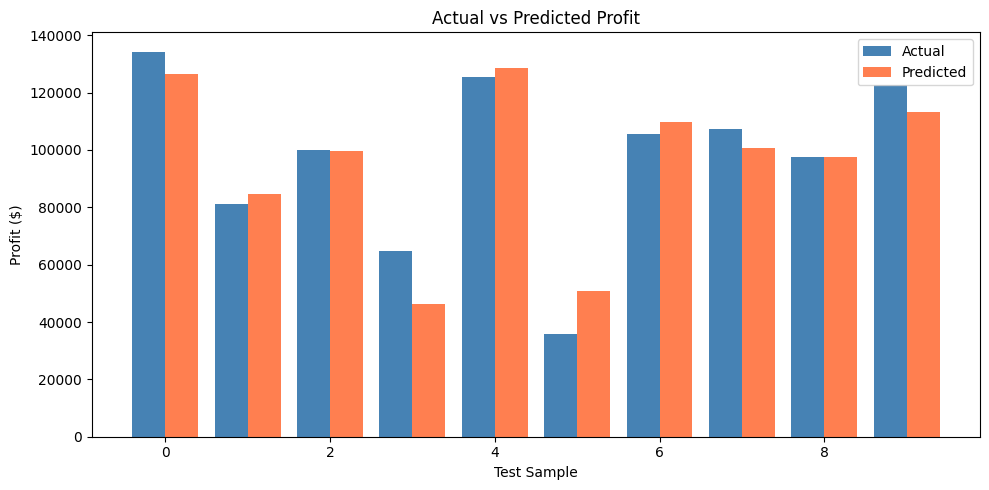

In [12]:
# ── Step 8: Actual vs Predicted Chart ────────────────
x_axis = range(len(y_test))

plt.figure(figsize=(10, 5))
plt.bar([i - 0.2 for i in x_axis], y_test.values,
        width=0.4, label='Actual',    color='steelblue')
plt.bar([i + 0.2 for i in x_axis], y_pred,
        width=0.4, label='Predicted', color='coral')
plt.xlabel('Test Sample')
plt.ylabel('Profit ($)')
plt.title('Actual vs Predicted Profit')
plt.legend()
plt.tight_layout()
plt.savefig('actual_vs_predicted.png')

In [13]:
plt.show()

In [14]:
print("\nDone! Charts saved as PNG files.")


Done! Charts saved as PNG files.
